In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
os.makedirs("../charts", exist_ok=True)

print("✅ All libraries imported!")

✅ All libraries imported!


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
os.makedirs("../charts", exist_ok=True)
COLORS = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
print("✅ All libraries imported!")

In [ ]:
 Bluestock Mutual Fund — EDA Analysis
## Data Overview
- **40 schemes** across 10 fund houses
- **46,000 NAV records** from Jan 2022 to Dec 2025
- **32,778 investor transactions** across 15 states
- **10 benchmark indices** tracked daily

In [4]:
top10 = nav.groupby("amfi_code")["nav"].last().nlargest(10).index.tolist()
nav10 = nav[nav["amfi_code"].isin(top10)].merge(fund[["amfi_code","scheme_name"]], on="amfi_code")
nav10["label"] = nav10["scheme_name"].str[:28]

fig = go.Figure()
for i, code in enumerate(top10):
    d = nav10[nav10["amfi_code"]==code].sort_values("date")
    fig.add_trace(go.Scatter(x=d["date"], y=d["nav"], mode="lines",
                             name=d["label"].iloc[0], line=dict(width=1.8, color=COLORS[i%10])))

fig.add_vrect(x0="2023-03-01", x1="2023-08-31", fillcolor="rgba(0,200,100,0.10)",
              line_width=0, annotation_text="2023 Bull Run",
              annotation_position="top left", annotation_font_color="green")
fig.add_vrect(x0="2024-03-01", x1="2024-04-30", fillcolor="rgba(255,50,50,0.10)",
              line_width=0, annotation_text="2024 Correction",
              annotation_position="top left", annotation_font_color="red")
fig.add_vrect(x0="2024-10-01", x1="2024-11-30", fillcolor="rgba(255,50,50,0.10)", line_width=0)

fig.update_layout(title="NAV Trend — Top 10 Schemes (2022–2025)",
                  xaxis_title="Date", yaxis_title="NAV (₹)",
                  width=1100, height=550,
                  plot_bgcolor="white", paper_bgcolor="white")
fig.show()
fig.write_image("../charts/01_nav_trend.png", scale=2)
print("✅ Chart 1 saved!")

NameError: name 'nav' is not defined

# User
-------------------------------------------------
NameError       Traceback (most recent call last)
Cell In[4], line 1
----> 1 top10 = nav.groupby("amfi_code")["nav"].last().nlargest(10).index.tolist()
      2 nav10 = nav[nav["amfi_code"].isin(top10)].merge(fund[["amfi_code","scheme_name"]], on="amfi_code")
      3 nav10["label"] = nav10["scheme_name"].str[:28]

NameError: name 'nav' is not defined

# Assistant
The error you're encountering is a `NameError` because the variable `nav` has not been defined in your current Python session. This typically happens when:

1. You haven't loaded your data yet
2. You're running cells out of order
3. The kernel was restarted and variables were cleared

To resolve this issue, you need to first define the `nav` variable by loading your data. Here's how you can fix it:


In [6]:
import pandas as pd

# Load your NAV data (replace with your actual data source)
# Option 1: If reading from a CSV file
nav = pd.read_csv('your_nav_file.csv')

# Option 2: If reading from Excel
# nav = pd.read_excel('your_nav_file.xlsx')

# Option 3: If you have the data in another format, load it accordingly
# nav = pd.read_json('your_nav_file.json')  # for JSON
# nav = pd.read_sql('SELECT * FROM nav_table', connection)  # for database

# Also load the fund data if not already loaded
fund = pd.read_csv('your_fund_file.csv')  # or appropriate loading method

# Now your original code should work
top10 = nav.groupby("amfi_code")["nav"].last().nlargest(10).index.tolist()
nav10 = nav[nav["amfi_code"].isin(top10)].merge(fund[["amfi_code","scheme_name"]], on="amfi_code")
nav10["label"] = nav10["scheme_name"].str[:28]

FileNotFoundError: [Errno 2] No such file or directory: 'your_nav_file.csv'


**Key points to remember:**
- Make sure to run the data loading cells before running analysis cells
- Verify that your data files contain the expected columns (`amfi_code`, `nav`, `scheme_name`)
- If you're working in a Jupyter notebook, ensure cells are executed in the correct order

**Recommended packages for data handling:**
- `pandas` for data manipulation and analysis
- `numpy` for numerical operations
- `openpyxl` or `xlrd` if working with Excel files

In [7]:
import pandas as pd

nav = pd.read_csv("nav.csv")
fund = pd.read_csv("fund_master.csv")  # agar ye file hai

top10 = nav.groupby("amfi_code")["nav"].last().nlargest(10).index.tolist()

print(top10)

FileNotFoundError: [Errno 2] No such file or directory: 'nav.csv'

In [8]:
import os

print(os.getcwd())      # current folder
print(os.listdir())     # folder me kaunsi files hain

C:\Users\Dilra\Desktop\mutual_fund_project
['.git', '.ipynb_checkpoints', 'anaconda_projects', 'bluestock_mf.db', 'charts', 'clean_data.py', 'create_database.py', 'dashboard', 'data', 'data_dictionary.md', 'data_ingestion.py', 'EDA_Analysis.ipynb', 'explore_fund_master.py', 'live_nav_fetch.py', 'notebooks', 'reports', 'requirements.txt', 'schema.sql', 'sql', 'validate_data.py']


In [9]:
import os

print(os.listdir("data"))

['processed', 'raw']


In [10]:
import os

print("RAW FILES:")
print(os.listdir("data/raw"))

print("\nPROCESSED FILES:")
print(os.listdir("data/processed"))

RAW FILES:
['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'ai_student_impact_dataset (1).csv', 'data.csv', 'global_nuclear_energy_intelligence_1965_2025.csv', 'movies.csv', 'placement_dataset.csv', 'rzp-key.csv']

PROCESSED FILES:
['01_fund_master.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv']


In [11]:
import pandas as pd

nav = pd.read_csv("data/processed/02_nav_history_clean.csv")
fund = pd.read_csv("data/processed/01_fund_master.csv")

print(nav.head())
print(fund.head())

   amfi_code        date       nav
0     118456  2022-01-03  111.8812
1     118456  2022-01-04  110.5585
2     118456  2022-01-05  111.0574
3     118456  2022-01-06  112.2870
4     118456  2022-01-07  111.0533
   amfi_code           fund_house                                 scheme_name  \
0     119551      SBI Mutual Fund   SBI Bluechip Fund - Regular Plan - Growth   
1     119552      SBI Mutual Fund    SBI Bluechip Fund - Direct Plan - Growth   
2     119598      SBI Mutual Fund  SBI Small Cap Fund - Regular Plan - Growth   
3     119599      SBI Mutual Fund   SBI Small Cap Fund - Direct Plan - Growth   
4     120503  ICICI Prudential MF  ICICI Pru Bluechip Fund - Regular - Growth   

  category sub_category     plan launch_date      benchmark  \
0   Equity    Large Cap  Regular  2006-02-14  NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01  NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2006-02-14  NIFTY 100 TRI   
3   Equity    Small Cap   Direct  2013-01-01  NIFTY

In [12]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [13]:
top10 = (
    nav.groupby("amfi_code")["nav"]
       .last()
       .nlargest(10)
       .index
       .tolist()
)

print(top10)

[118456, 119552, 120678, 120841, 120465, 119093, 125498, 118989, 118636, 118632]


In [14]:
top10 = nav.groupby("amfi_code")["nav"].last().nlargest(10).index.tolist()

top10_schemes = fund[fund["amfi_code"].isin(top10)][
    ["amfi_code", "scheme_name"]
]

print(top10_schemes)

    amfi_code                                  scheme_name
1      119552     SBI Bluechip Fund - Direct Plan - Growth
7      125498     HDFC Top 100 Fund - Direct Plan - Growth
8      118632    Nippon India Large Cap - Regular - Growth
11     119093    Axis Bluechip Fund - Direct Plan - Growth
12     120841  Kotak Bluechip Fund - Regular Plan - Growth
16     118636    Nippon India Small Cap - Regular - Growth
20     120465     ICICI Pru Midcap Fund - Regular - Growth
24     118989    Nippon India Multi Cap - Regular - Growth
34     120678   Franklin India Bluechip - Regular - Growth
38     118456      Mirae Asset Emerging Bluechip - Regular


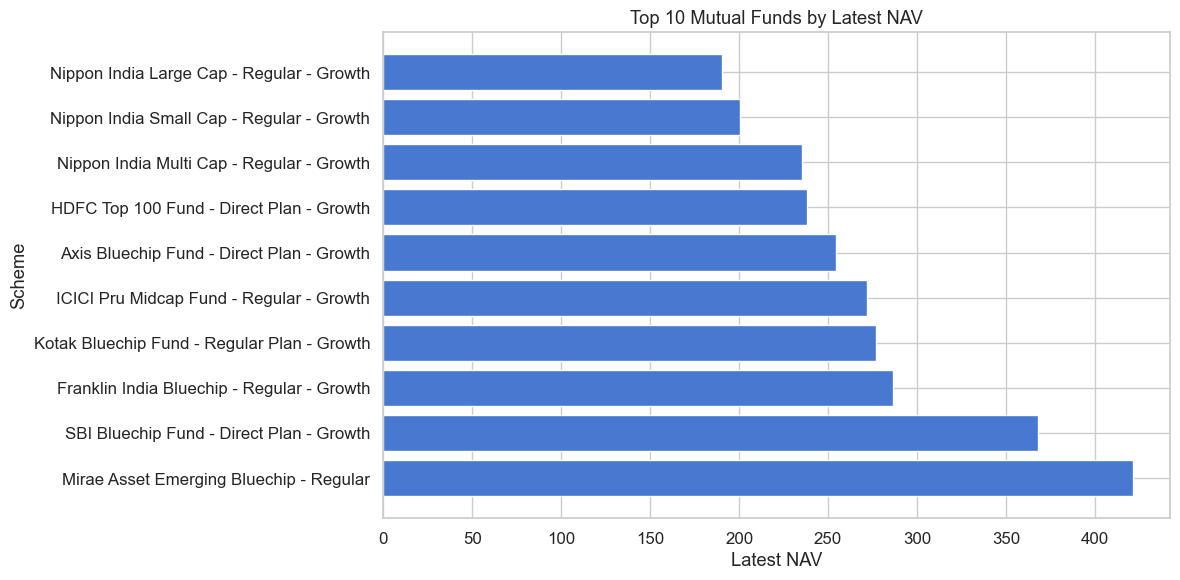

In [48]:
import matplotlib.pyplot as plt

top10_nav = (
    nav.groupby("amfi_code")["nav"]
       .last()
       .nlargest(10)
       .reset_index()
)

top10_nav = top10_nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

plt.figure(figsize=(12,6))
plt.barh(top10_nav["scheme_name"], top10_nav["nav"])
plt.xlabel("Latest NAV")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Funds by Latest NAV")
plt.tight_layout()
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
aum["year"] = aum["date"].dt.year
top6 = aum.groupby("fund_house")["aum_crore"].mean().nlargest(6).index.tolist()
aum_plot = aum[aum["fund_house"].isin(top6)].groupby(["year","fund_house"])["aum_crore"].mean().reset_index()
aum_plot["aum_lakh_cr"] = aum_plot["aum_crore"] / 100000

fig, ax = plt.subplots(figsize=(14,7))
x = np.arange(4)
years = [2022,2023,2024,2025]
w = 0.13
for i, fh in enumerate(top6):
    vals = [aum_plot[(aum_plot["year"]==yr)&(aum_plot["fund_house"]==fh)]["aum_lakh_cr"].values for yr in years]
    vals = [v[0] if len(v) else 0 for v in vals]
    bars = ax.bar(x+i*w, vals, w, label=fh[:20], color=COLORS[i], alpha=0.88, edgecolor="white")
    if fh == "SBI Mutual Fund":
        for bar, val in zip(bars, vals):
            ax.annotate(f"₹{val:.1f}L Cr", xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                        xytext=(0,5), textcoords="offset points",
                        ha="center", fontsize=8, color="#d62728", fontweight="bold")

ax.set_xticks(x+w*2.5)
ax.set_xticklabels(years, fontsize=12)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("AUM (₹ Lakh Crore)", fontsize=13)
ax.set_title("AUM Growth by Fund House — 2022 to 2025\n(SBI dominance annotated)", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../charts/02_aum_growth.png", dpi=180, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved!")

NameError: name 'aum' is not defined

In [17]:
NameError: name 'aum' is not defined

SyntaxError: invalid syntax (3460412286.py, line 1)

In [18]:
aum.head()


NameError: name 'aum' is not defined

In [19]:
%whos

Variable               Type         Data/Info
---------------------------------------------
COLORS                 list         n=10
dataframe_columns      function     <function dataframe_colum<...>ns at 0x0000022702ACF240>
dataframe_hash         function     <function dataframe_hash at 0x0000022702ACFE20>
dtypes_str             function     <function dtypes_str at 0x0000022702ACEDE0>
fund                   DataFrame    Shape: (40, 15)
get_dataframes         function     <function get_dataframes at 0x0000022702A49300>
getpass                module       <module 'getpass' from 'C<...>conda3\\Lib\\getpass.py'>
go                     module       <module 'plotly.graph_obj<...>ph_objects\\__init__.py'>
hashlib                module       <module 'hashlib' from 'C<...>conda3\\Lib\\hashlib.py'>
import_pandas_safely   function     <function import_pandas_s<...>ly at 0x0000022702A4A0C0>
is_data_frame          function     <function is_data_frame at 0x0000022702A49BC0>
json                   m

In [20]:
fund.head()


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2006-02-14,NIFTY 100 TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,NIFTY 100 TRI,0.55,1.0,500,1000,R. Srinivasan,Very High,EC03
4,120503,ICICI Prudential MF,ICICI Pru Bluechip Fund - Regular - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.61,1.0,500,1000,Anish Tawakley,Moderate,EC01


In [21]:
fund.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [22]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [23]:
top10 = (
    nav.groupby("amfi_code")["nav"]
       .last()
       .nlargest(10)
       .index
       .tolist()
)

print(top10)

[118456, 119552, 120678, 120841, 120465, 119093, 125498, 118989, 118636, 118632]


In [24]:
top10 = nav.groupby("amfi_code")["nav"].last().nlargest(10).index.tolist()

top10_schemes = fund[fund["amfi_code"].isin(top10)][
    ["amfi_code", "scheme_name"]
]

print(top10_schemes)

    amfi_code                                  scheme_name
1      119552     SBI Bluechip Fund - Direct Plan - Growth
7      125498     HDFC Top 100 Fund - Direct Plan - Growth
8      118632    Nippon India Large Cap - Regular - Growth
11     119093    Axis Bluechip Fund - Direct Plan - Growth
12     120841  Kotak Bluechip Fund - Regular Plan - Growth
16     118636    Nippon India Small Cap - Regular - Growth
20     120465     ICICI Pru Midcap Fund - Regular - Growth
24     118989    Nippon India Multi Cap - Regular - Growth
34     120678   Franklin India Bluechip - Regular - Growth
38     118456      Mirae Asset Emerging Bluechip - Regular


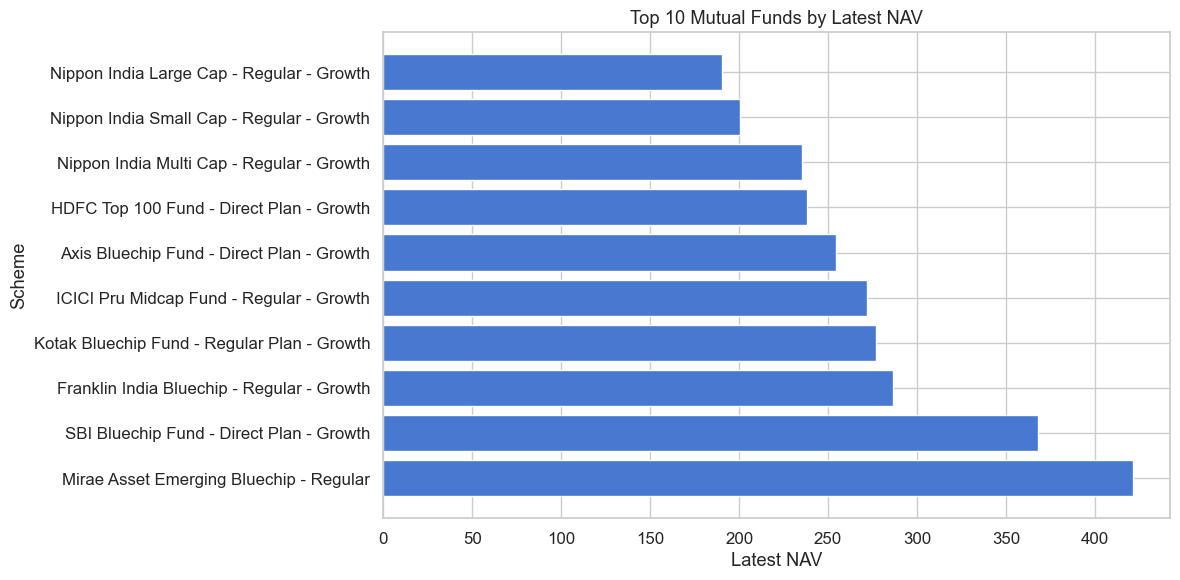

In [25]:
import matplotlib.pyplot as plt

top10_nav = (
    nav.groupby("amfi_code")["nav"]
       .last()
       .nlargest(10)
       .reset_index()
)

top10_nav = top10_nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

plt.figure(figsize=(12,6))
plt.barh(top10_nav["scheme_name"], top10_nav["nav"])
plt.xlabel("Latest NAV")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Funds by Latest NAV")
plt.tight_layout()
plt.show()

In [49]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=sip["month_dt"], y=sip["sip_inflow_crore"],
                         mode="lines+markers", name="SIP Inflow",
                         line=dict(color="#1f77b4", width=2.5), marker=dict(size=5)))

ath = sip.loc[sip["sip_inflow_crore"].idxmax()]
fig.add_annotation(x=ath["month_dt"], y=ath["sip_inflow_crore"],
                   text=f"🏆 All-Time High<br>₹{int(ath['sip_inflow_crore']):,} Cr<br>Dec 2025",
                   showarrow=True, arrowhead=2, ax=0, ay=-60,
                   bgcolor="rgba(255,215,0,0.9)", bordercolor="#ff7f0e",
                   borderwidth=2, font=dict(size=12))

fig.update_layout(title="Monthly SIP Inflow — Jan 2022 to Dec 2025",
                  xaxis_title="Month", yaxis_title="₹ Crore",
                  width=1100, height=500,
                  plot_bgcolor="white", paper_bgcolor="white")
fig.write_image("charts/chart_name.png", scale=2)
fig.show()
fig.write_image("../charts/03_sip_inflow.png", scale=2)
print("✅ Chart 3 saved!")

KeyError: 'month_dt'

In [27]:
print(txn.columns.tolist())

NameError: name 'txn' is not defined

In [28]:
import pandas as pd

fund = pd.read_csv("data/processed/01_fund_master.csv")
nav = pd.read_csv("data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/processed/04_monthly_sip_inflows.csv")
cat = pd.read_csv("data/processed/05_category_inflows.csv")
folio = pd.read_csv("data/processed/06_industry_folio_count.csv")
perf = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("data/processed/08_investor_transactions_clean.csv")
hold = pd.read_csv("data/processed/09_portfolio_holdings.csv")
bench = pd.read_csv("data/processed/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [29]:
print(txn.shape)
print(txn.columns.tolist())

(32778, 13)
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [30]:
nav["date"] = pd.to_datetime(nav["date"])
sip["month_dt"] = pd.to_datetime(sip["month_dt"])
cat["month_dt"] = pd.to_datetime(cat["month_dt"])
folio["month_dt"] = pd.to_datetime(folio["month_dt"])
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])
bench["date"] = pd.to_datetime(bench["date"])

KeyError: 'month_dt'

In [31]:
print(sip.columns.tolist())
print(cat.columns.tolist())
print(folio.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
['month', 'category', 'net_inflow_crore']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [32]:
sip["month"] = pd.to_datetime(sip["month"])
cat["month"] = pd.to_datetime(cat["month"])
folio["month"] = pd.to_datetime(folio["month"])

nav["date"] = pd.to_datetime(nav["date"])
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])
bench["date"] = pd.to_datetime(bench["date"])

In [33]:
x=sip["month"]

In [34]:
ath["month_dt"]

NameError: name 'ath' is not defined

In [35]:
ath["month"]

NameError: name 'ath' is not defined

In [36]:
print("TXN")
print(txn.columns.tolist())

print("\nPERF")
print(perf.columns.tolist())

print("\nHOLD")
print(hold.columns.tolist())

print("\nBENCH")
print(bench.columns.tolist())

print("\nSIP")
print(sip.columns.tolist())

print("\nFOLIO")
print(folio.columns.tolist())

print("\nCAT")
print(cat.columns.tolist())

TXN
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

PERF
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

HOLD
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

BENCH
['date', 'index_name', 'close_value']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

FOLIO
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

CAT
['month', 'category', 'net_inflow_crore']


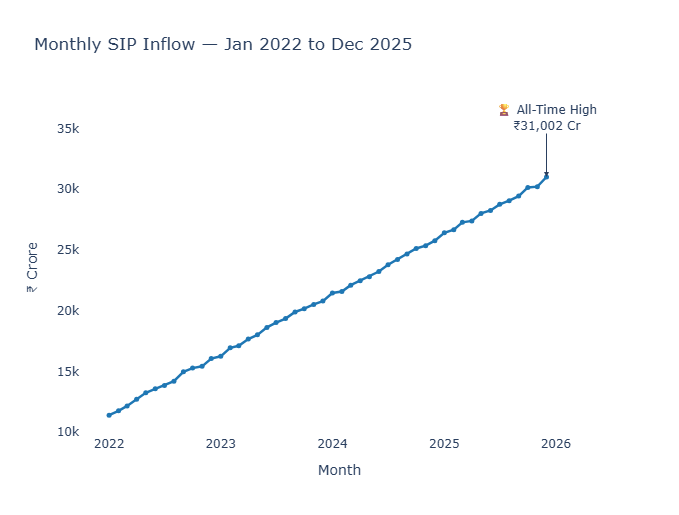

In [37]:
import plotly.graph_objects as go

sip["month"] = pd.to_datetime(sip["month"])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=sip["month"],
        y=sip["sip_inflow_crore"],
        mode="lines+markers",
        name="SIP Inflow",
        line=dict(color="#1f77b4", width=2.5),
        marker=dict(size=5)
    )
)

ath = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=ath["month"],
    y=ath["sip_inflow_crore"],
    text=f"🏆 All-Time High<br>₹{int(ath['sip_inflow_crore']):,} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60
)

fig.update_layout(
    title="Monthly SIP Inflow — Jan 2022 to Dec 2025",
    xaxis_title="Month",
    yaxis_title="₹ Crore",
    width=1100,
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

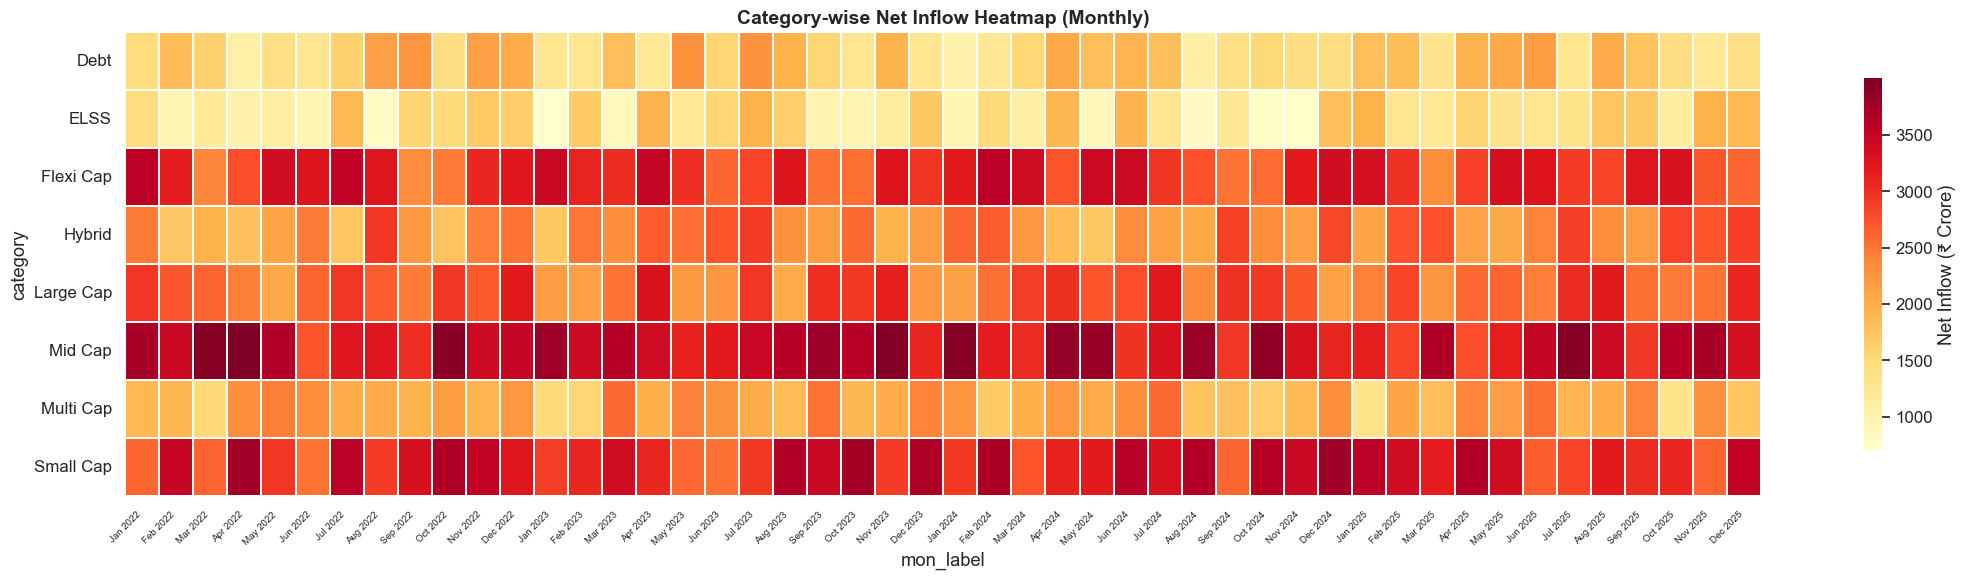

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

cat["month"] = pd.to_datetime(cat["month"])

cat["mon_label"] = cat["month"].dt.strftime("%b %Y")

heat = cat.pivot_table(
    index="category",
    columns="mon_label",
    values="net_inflow_crore",
    aggfunc="sum"
)

col_order = (
    cat.drop_duplicates("mon_label")
       .sort_values("month")["mon_label"]
       .tolist()
)

heat = heat.reindex(columns=col_order)

fig, ax = plt.subplots(figsize=(22,6))

sns.heatmap(
    heat,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.3,
    cbar_kws={"label":"Net Inflow (₹ Crore)","shrink":0.8}
)

ax.set_title(
    "Category-wise Net Inflow Heatmap (Monthly)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=7
)

plt.tight_layout()
plt.show()

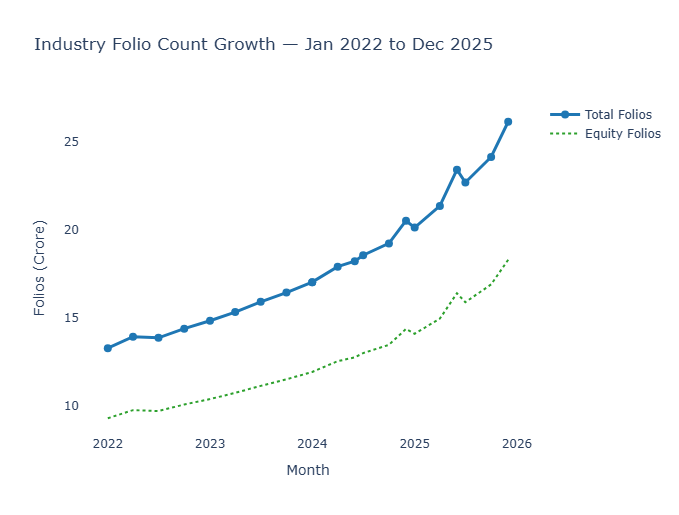

In [39]:
import plotly.graph_objects as go

folio["month"] = pd.to_datetime(folio["month"])

folio_s = folio.sort_values("month")

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=folio_s["month"],
        y=folio_s["total_folios_crore"],
        mode="lines+markers",
        name="Total Folios",
        line=dict(color="#1f77b4", width=3),
        marker=dict(size=8)
    )
)

fig.add_trace(
    go.Scatter(
        x=folio_s["month"],
        y=folio_s["equity_folios_crore"],
        mode="lines",
        name="Equity Folios",
        line=dict(color="#2ca02c", width=2, dash="dot")
    )
)

fig.update_layout(
    title="Industry Folio Count Growth — Jan 2022 to Dec 2025",
    xaxis_title="Month",
    yaxis_title="Folios (Crore)",
    width=1100,
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

In [40]:
import pandas as pd

fund = pd.read_csv("data/processed/01_fund_master.csv")
nav = pd.read_csv("data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/processed/04_monthly_sip_inflows.csv")
cat = pd.read_csv("data/processed/05_category_inflows.csv")
folio = pd.read_csv("data/processed/06_industry_folio_count.csv")
perf = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("data/processed/08_investor_transactions_clean.csv")
hold = pd.read_csv("data/processed/09_portfolio_holdings.csv")
bench = pd.read_csv("data/processed/10_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])
bench["date"] = pd.to_datetime(bench["date"])
sip["month"] = pd.to_datetime(sip["month"])
cat["month"] = pd.to_datetime(cat["month"])
folio["month"] = pd.to_datetime(folio["month"])

print("✅ All datasets loaded")

✅ All datasets loaded


In [41]:
import os
print(os.listdir("charts"))

[]


In [42]:
import os
print(os.listdir("charts"))

[]


In [43]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nCharts folder exists?")
print(os.path.exists("charts"))

print("\nFiles in current folder:")
print(os.listdir())

print("\nSearching for all PNG files...\n")

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".png"):
            print(os.path.join(root, file))

Current Folder:
C:\Users\Dilra\Desktop\mutual_fund_project

Charts folder exists?
True

Files in current folder:
['.git', '.ipynb_checkpoints', 'anaconda_projects', 'bluestock_mf.db', 'charts', 'clean_data.py', 'create_database.py', 'dashboard', 'data', 'data_dictionary.md', 'data_ingestion.py', 'EDA_Analysis.ipynb', 'explore_fund_master.py', 'live_nav_fetch.py', 'notebooks', 'reports', 'requirements.txt', 'schema.sql', 'sql', 'validate_data.py']

Searching for all PNG files...



In [44]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder ready!")

Charts folder ready!


In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot([1,2,3,4],[10,20,15,30])

plt.title("Test Chart")

plt.savefig("charts/test_chart.png", dpi=300, bbox_inches="tight")

plt.close()

print("Saved Successfully")

Saved Successfully


In [46]:
import os
print(os.listdir("charts"))

['test_chart.png']


In [47]:
import os
import matplotlib.pyplot as plt

os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(5,3))
plt.plot([1,2,3,4],[10,20,15,30])
plt.title("Test Chart")

plt.savefig("charts/test_chart.png", dpi=300, bbox_inches="tight")
plt.close()

print("Files in charts folder:")
print(os.listdir("charts"))

Files in charts folder:
['test_chart.png']


In [50]:
import os

print(os.listdir("charts"))

['chart_name.png', 'test_chart.png']


In [51]:
import os

png_files = [f for f in os.listdir("charts") if f.endswith(".png")]

print("Total PNG Files:", len(png_files))
print(png_files)

Total PNG Files: 2
['chart_name.png', 'test_chart.png']


In [52]:
import shutil
import os

if os.path.exists("charts"):
    shutil.rmtree("charts")

os.makedirs("charts")

print("Charts folder reset!")



Charts folder reset!


In [53]:
01_nav_trend.png
02_aum_growth.png
03_sip_inflow.png
04_category_heatmap.png
05_demographics.png
06_geographic.png
07_folio_growth.png
08_correlation_matrix.png
09_sector_donut.png
10_risk_return.png
11_transaction_trend.png
12_morningstar.png
13_benchmark.png
14_payment_kyc.png
15_expense_ratio.png

SyntaxError: invalid decimal literal (854231768.py, line 1)